In [1]:
import numpy as np
import empylib.miescattering as mie

# <a id='toc1_'></a>[Testing Percus-Yevick model of hard spheres](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Testing Percus-Yevick model of hard spheres](#toc1_)    
  - [Validating Monodispersed case](#toc1_1_)    
  - [Validating polydispersed case](#toc1_2_)    
  - [Testing phase function](#toc1_3_)    
    - [Input parameters](#toc1_3_1_)    
    - [Comparing phase function agains single sphere](#toc1_3_2_)    
    - [Comparing scattering parameters obtained from phase function](#toc1_3_3_)    
  - [Testing Heyeney-Greenstein](#toc1_4_)    
    - [Comparing phase function from Mie-theory](#toc1_4_1_)    
  - [Validating Heyney-Greenstein for hard-spheres](#toc1_5_)    
    - [Comparing scattering parameters extracted from Heyney-Greenstein](#toc1_5_1_)    
    - [Comparing phase functions](#toc1_5_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Validating Monodispersed case](#toc0_)

/tmp/ipykernel_16586/3345865718.py:12: RuntimeWarning: invalid value encountered in arcsin
  theta = 2*np.arcsin(q/(2*k0))


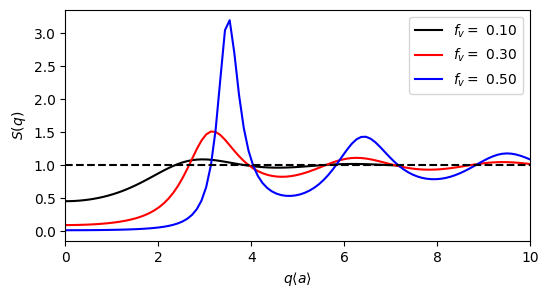

In [2]:
import matplotlib.pyplot as plt
fv = np.array([0.10, 0.30, 0.50]) # volume fractions
lam = 0.5
Nh = 1.0
k0 = 2*np.pi/lam*Nh
R_mean = (3/(4*np.pi)*fv)**(1/3)
line_color = ['k', 'r', 'b']

fig, ax = plt.subplots(figsize = (6,3))
for i in range(len(fv)):
    q = np.linspace(0,10,100)/R_mean[i]
    theta = 2*np.arcsin(q/(2*k0))

    # Sq = structure_factor_PY(fv[i], lam, Nh, theta, 2*R, nD)
    Sq = mie.structure_factor_PY(lam, Nh, 2*R_mean[i], fv[i], theta = theta)
    ax.plot(q*R_mean[i], Sq[:,0], color = line_color[i], label = '$f_v =$ %.2f' % (fv[i]))

ax.plot(q*R_mean[i], np.ones_like(q), '--k')
ax.set_xlabel(r'$q\langle a \rangle$')
ax.set_ylabel(r'$S(q)$')
# ax.set_ylim(0.5, 1.2)
ax.set_xlim(0,10)
plt.legend()
plt.show()

## <a id='toc1_2_'></a>[Validating polydispersed case](#toc0_)

We want to validate the Percus-Yevick model for polydispersed hard spheres. The model is original from [Botet et al (2020), "Percus-Yevick structure factors made simple"](https://onlinelibrary-wiley-com.uai.idm.oclc.org/iucr/doi/10.1107/S1600576720014041) 

First, we import the data from Botet et al (2020), Fig. 2

In [3]:
import pandas as pd
df_black = pd.read_csv('./Botet_results/Botet_validateFig2_black-line.csv', index_col = 0, header = None)
df_blue = pd.read_csv('./Botet_results/Botet_validateFig2_blue-line.csv', index_col = 0)
df_red = pd.read_csv('./Botet_results/Botet_validateFig2_red-line.csv', index_col = 0)

Now, we run `mie.struture_factor_PY` to validate the model

/tmp/ipykernel_16586/3951631826.py:16: RuntimeWarning: invalid value encountered in arcsin
  theta = 2*np.arcsin(q/(2*k0))


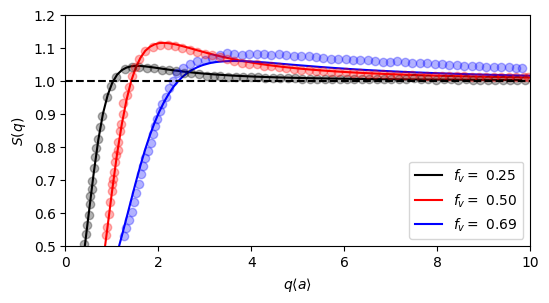

In [4]:
import matplotlib.pyplot as plt
fv = np.array([0.25, 0.50, 0.69]) # volume fractions
lam = 0.5
Nh = 1.0
k0 = 2*np.pi/lam*Nh
R_mean = (3/(4*np.pi)*fv)**(1/3)
line_color = ['k', 'r', 'b']

fig, ax = plt.subplots(figsize = (6,3))
for i in range(len(fv)):
    # if i != 0: continue
    R = np.linspace(1E-5,10*R_mean[i],100)
    nD = np.exp(-R/R_mean[i])
    nD = nD/np.trapz(nD, R)
    q = np.linspace(0,10,100)/R_mean[i]
    theta = 2*np.arcsin(q/(2*k0))

    Sq = mie.structure_factor_PY(lam, Nh, 2*R, fv[i], size_dist = nD, theta = theta)
    ax.plot(q*R_mean[i], Sq[:,0], color = line_color[i], label = '$f_v =$ %.2f' % (fv[i]))

plt.plot(df_black.index,df_black,'o k', alpha = 0.3, mfc = None)
plt.plot(df_blue.index,df_blue,'o b', alpha = 0.3, mfc = None)
plt.plot(df_red.index,df_red,'o r', alpha = 0.3, mfc = None)
ax.plot(q*R_mean[i], np.ones_like(q), '--k')
ax.set_xlabel(r'$q\langle a \rangle$')
ax.set_ylabel(r'$S(q)$')
ax.set_ylim(0.5, 1.2)
ax.set_xlim(0,10)
plt.legend()
plt.show()

## <a id='toc1_3_'></a>[Testing phase function](#toc0_)

In [5]:
help(mie.phase_scatt_ensemble)

Help on function phase_scatt_ensemble in module empylib.miescattering:

phase_scatt_ensemble()
    Calculate the scattering phase function for multiple hard-spheres under unpolarized light. 
    The intensity is normalized such that the integral is equal to qsca
    
    Parameters:
        wavelength : ndarray or float 
            Wavelengtgh (microns)
        
        Nh : ndarray or float 
            Complex refractive index of host. If ndarray, len(Nh) == len(wavelength)
    
        Np (float, 1darray or list): Complex refractive index of each 
                                            shell layer. Np.shape[1] == len(D). 
            Options are:
            float:   solid sphere and constant refractive index
            1darray: solid sphere and spectral refractive index (len = wavelength)
            list:    multilayered sphere (with both constant or spectral refractive indexes)
        
        D : float, _np.ndarray or list
            Diameter of the spheres. Use float f

### <a id='toc1_3_1_'></a>[Input parameters](#toc0_)

In [6]:
import empylib.nklib as nk

theta = np.radians(np.linspace(0,360,361))
lam = np.linspace(0.3,2.0,200)
Dp = 1.0
Np = nk.SiO2(lam)
nk_air = 1.0
fv = 0.4
Nh = nk_air
Nh_eff = nk.emt_brugg(fv, Np, Nh)

In [7]:
# adjust theta values for plotting
theta_plot = np.zeros_like(theta)
theta_positive = theta[(theta>=0) & (theta<=np.pi)]
theta_negative = theta[(theta>np.pi) & (theta<=2*np.pi)] 
theta_plot[:len(theta_negative)] = theta_negative
theta_plot[len(theta_negative):] = theta_positive 
theta_plot = np.degrees(theta_plot) # renders theta values (in degrees) for DataFrame indexing

theta_xaxis = theta_plot - 360*(theta_plot > 180) # renders theta values for x-axis plotting (-180 to 180 degrees)

### <a id='toc1_3_2_'></a>[Comparing phase function agains single sphere](#toc0_)

In [8]:

phase_scat_mie = mie.phase_scatt_ensemble(lam, Nh, Np, Dp, fv,
                                          theta=theta,
                                          effective_medium = True,)

phase_scat_dense = mie.phase_scatt_ensemble(lam, Nh, Np, Dp, fv, 
                                            theta=theta,
                                            dependent_scatt = True,
                                            effective_medium = True,)

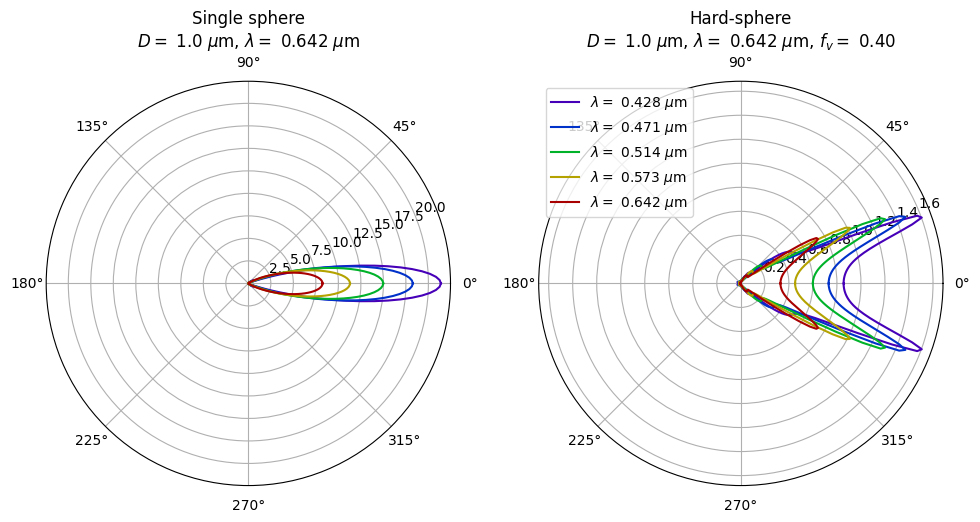

In [9]:
from empylib.color_system import spectrum_to_hex

ilam = [15, 20, 25, 32, 40]
fig, ax = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize = (10,5))
for i, idx in enumerate(ilam):
    crgb = spectrum_to_hex(lam, np.isclose(lam, lam[idx], atol = 0.02), 
                           source = 'material')[0]

    ax[0].plot(theta, phase_scat_mie[lam[idx]], '-', color=crgb, label = f'$\lambda =$ %.3f $\mu$m' % lam[idx])
    ax[0].set_title('Single sphere\n$D =$ %.1f $\mu$m, $\lambda =$ %.3f $\mu$m' % (Dp, lam[idx]))
    ax[1].plot(theta, phase_scat_dense[lam[idx]], '-', color=crgb, label = f'$\lambda =$ %.3f $\mu$m' % lam[idx])
    ax[1].set_title('Hard-sphere\n$D =$ %.1f $\mu$m, $\lambda =$ %.3f $\mu$m, $f_v =$ %.2f' % (Dp, lam[idx], fv))
# y_max = max(phase_scat[lam[idx]].max(), phase_scat_dense[lam[idx]].max())*1.1
# plt.ylim(top = y_max)
plt.legend()
plt.tight_layout()
plt.show()

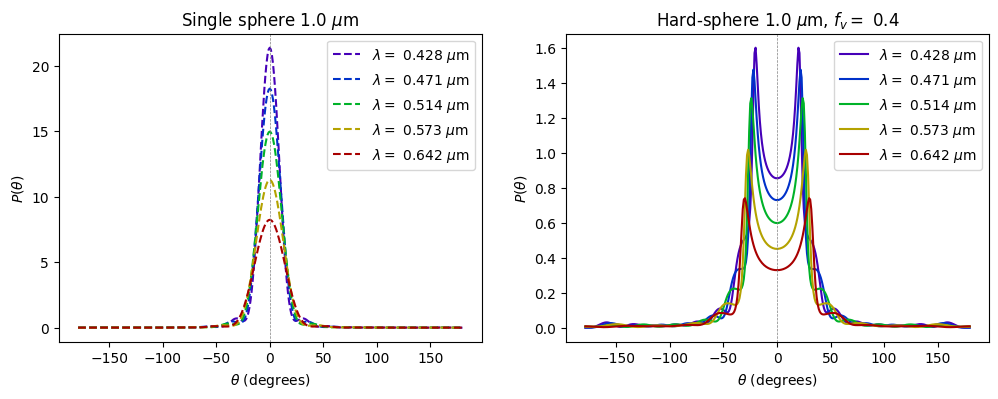

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ilam = [15, 20, 25, 32, 40]
for i, idx in enumerate(ilam):
    crgb = spectrum_to_hex(lam, np.isclose(lam, lam[idx], atol = 0.02), 
                            source = 'material')[0]
    ax[0].plot(theta_xaxis, phase_scat_mie[lam[idx]][theta_plot], '--', color = crgb, label=f'$\lambda =$ %.3f $\mu$m' % lam[idx])
    ax[1].plot(theta_xaxis, phase_scat_dense[lam[idx]][theta_plot], '-', color = crgb, label=f'$\lambda =$ %.3f $\mu$m' % lam[idx])

title_str = [f'Single sphere {Dp} $\mu$m', f'Hard-sphere {Dp} $\mu$m, $f_v =$ {fv}']
for j, ax in enumerate(ax):
    ax.set_xlabel(r'$\theta$ (degrees)')
    ax.set_ylabel(r'$P(\theta)$')
    ax.set_title(title_str[j])
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.legend()
# ax.set_xlim(-50,50)
plt.show()

### <a id='toc1_3_3_'></a>[Comparing scattering parameters obtained from phase function](#toc0_)

In [11]:
help(mie.scatter_from_phase_function)

Help on function scatter_from_phase_function in module empylib.miescattering:

scatter_from_phase_function()
    Compute Qsca and <cos theta> from a DataFrame whose rows are labeled
    with scattering angles in degrees and columns with wavelengths.
    
    This implementation supports two integration backends over mu = cos(theta):
    - ``gauss``: Gauss-Legendre quadrature.
    - ``trapz``: trapezoidal rule in mu-space.
    Integration method selection is centralized in one internal router.
    
    Parameters
    ----------
    phase_fun : pd.DataFrame
        Phase function. Row index must be theta in degrees (not necessarily uniform).
        Columns correspond to different wavelengths.
    
    a_tol_deg : float
        Tolerance in degrees for verifying that the input theta grid covers 
        the needed range [0°, 180°] for integration. Default is 1 degree.
    
    Returns
    -------
    qsca : ndarray
        Scattering efficiency for each column.
    
    gcos : ndarray
  

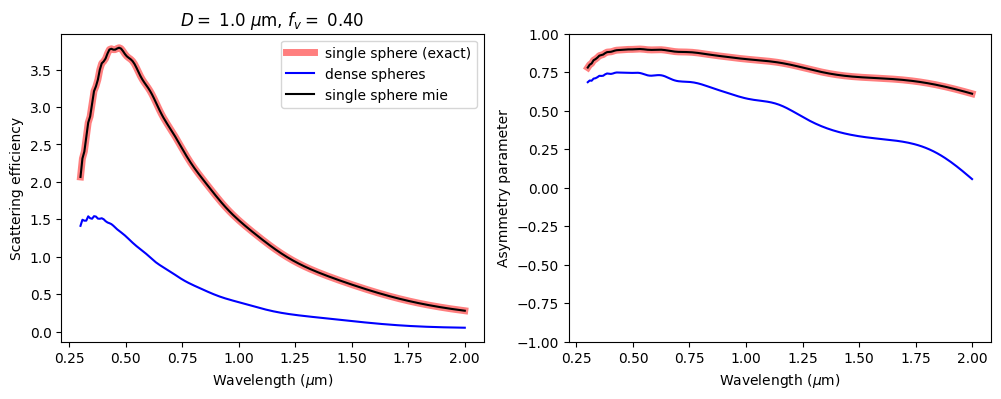

In [12]:
qsca_dense, gcos_dense = mie.scatter_from_phase_function(phase_scat_dense)
qsca_mie, gcos_mie = mie.scatter_from_phase_function(phase_scat_mie)
qabs, qsca, gcos = mie.scatter_efficiency(lam, Nh_eff, Np, Dp)

fig, ax = plt.subplots(1,2, figsize = (12,4))
ax[0].plot(lam, qsca, '-r', label = 'single sphere (exact)', lw = 5.0, alpha = 0.5)
ax[0].plot(lam, qsca_dense, '-b', label = 'dense spheres')
ax[0].plot(lam, qsca_mie, '-k', label = 'single sphere mie')
ax[0].legend()
ax[0].set_xlabel(r'Wavelength ($\mu$m)')
ax[0].set_ylabel('Scattering efficiency')

ax[1].plot(lam, gcos, '-r', label = 'single sphere', lw = 5.0, alpha = 0.5)
ax[1].plot(lam, gcos_dense, '-b', label = 'dense spheres')
ax[1].plot(lam, gcos_mie, '-k', label = 'single sphere mie')
ax[1].set_xlabel(r'Wavelength ($\mu$m)')
ax[1].set_ylabel('Asymmetry parameter')
ax[1].set_ylim(-1,1)
ax[0].set_title('$D =$ %.1f $\mu$m, $f_v =$ %.2f' % (Dp, fv))
plt.show()

## <a id='toc1_4_'></a>[Testing Heyeney-Greenstein](#toc0_)

We want to validate the Heyney-Greenstein model. If correct the extracted scattering parameters, $Q_\mathrm{sca}$ and $\mu_\mathrm{sca}$, should match exactly those from Mie theory

In [13]:
help(mie.phase_scatt_HG)

Help on function phase_scatt_HG in module empylib.miescattering:

phase_scatt_HG()
    Compute the Heyney-Greenstein phase function
    
    Parameters
        wavelength : ndarray or float
            wavelengtgh (microns)
    
        gcos : float or ndarray
            Asymmetry parameter
        
        qsca: float or ndarray (optional)
            Scattering efficiency. If 1, then integral of phase function = 1.
            Default 1
        
        theta : ndarray or float (optional)
            Scattering angle (radians). If None, then 0 to 2*_pi in 1 degree steps.
            Default None
        
        as_ndarray : bool (optional)
            True if user wants the output as ndarray. Otherwise, the output is a pd.DataFrame. Default False
    
    Return
        p_theta_HG: float or ndarray
            Phase function



In [14]:
qabs_HG, qsca_HG, gcos_HG = mie.scatter_efficiency(lam, Nh_eff, Np, Dp)
p_theta_HG = mie.phase_scatt_HG(lam, gcos_HG, qsca_HG, theta=theta)
p_theta_mie = mie.phase_scatt_ensemble(lam, Nh, Np, Dp, fv,
                                          theta=theta,
                                          effective_medium = True,)

In [15]:


# perform integration of phase function to verify normalization constant
i_lam = 40
mask = np.degrees(theta) <= 180

# testing normalization constant for HG phase function
norm_HG = np.trapz(p_theta_HG[lam[i_lam]][mask]*np.sin(theta[mask]), x = theta[mask]) * 2*np.pi/qsca_HG[i_lam]
print(f'1/qsca * ∫ ph_HG(Ω) dΩ = {norm_HG:.3f}')

# testing normalization constant for Mie Scattering phase function
norm_Mie = np.trapz(p_theta_mie[lam[i_lam]][mask]*np.sin(theta[mask]), x = theta[mask]) * 2*np.pi/qsca_mie[i_lam]
print(f'1/qsca * ∫ ph_Mie(Ω) dΩ = {norm_Mie:.3f}')

1/qsca * ∫ ph_HG(Ω) dΩ = 0.998
1/qsca * ∫ ph_Mie(Ω) dΩ = 1.000


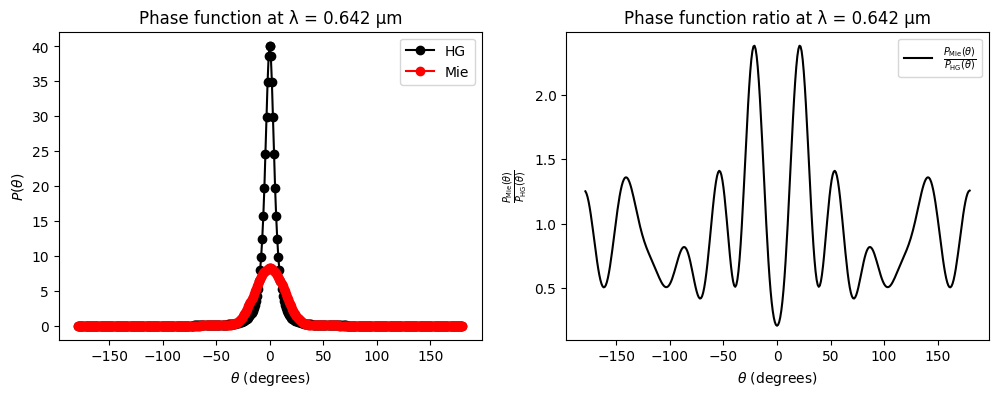

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

phase_function_ratio = phase_scat_mie[lam[i_lam]]/p_theta_HG[lam[i_lam]]

ax[0].plot(theta_xaxis, p_theta_HG[lam[i_lam]][theta_plot], 'o-k', label = 'HG')
ax[0].plot(theta_xaxis, p_theta_mie[lam[i_lam]][theta_plot], 'o-r', label = 'Mie')
ax[0].set_xlabel(r'$\theta$ (degrees)')
ax[0].set_ylabel(r'$P(\theta)$')
ax[0].set_title(f'Phase function at λ = {lam[i_lam]:.3f} μm')
ax[0].legend()


ax[1].plot(theta_xaxis, phase_function_ratio[theta_plot], '-k', label = rf'$\frac{{P_\mathrm{{Mie}}(\theta)}}{{P_\mathrm{{HG}}(\theta)}}$')
ax[1].set_xlabel(r'$\theta$ (degrees)')
ax[1].set_ylabel(r'$\frac{P_\mathrm{Mie}(\theta)}{P_\mathrm{HG}(\theta)}$')
ax[1].set_title(f'Phase function ratio at λ = {lam[i_lam]:.3f} μm')
ax[1].legend()
plt.show()

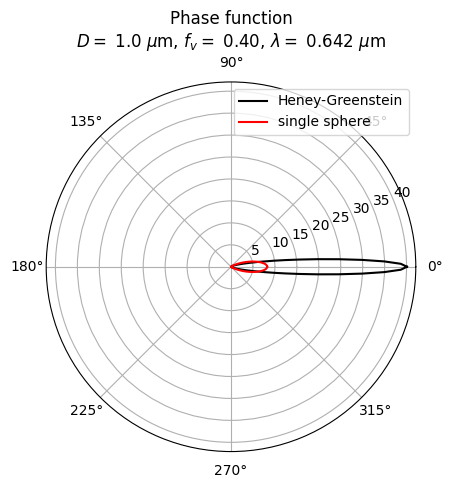

In [17]:
i_lam = 40
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(theta, p_theta_HG[lam[i_lam]], '-k', label = 'Heney-Greenstein')
ax.plot(theta, phase_scat_mie[lam[i_lam]], '-r', label = 'single sphere')
ax.set_title('Phase function\n$D =$ %.1f $\mu$m, $f_v =$ %.2f, $\lambda =$ %.3f $\mu$m' % (Dp, fv, lam[i_lam]))
ax.legend()
plt.show()

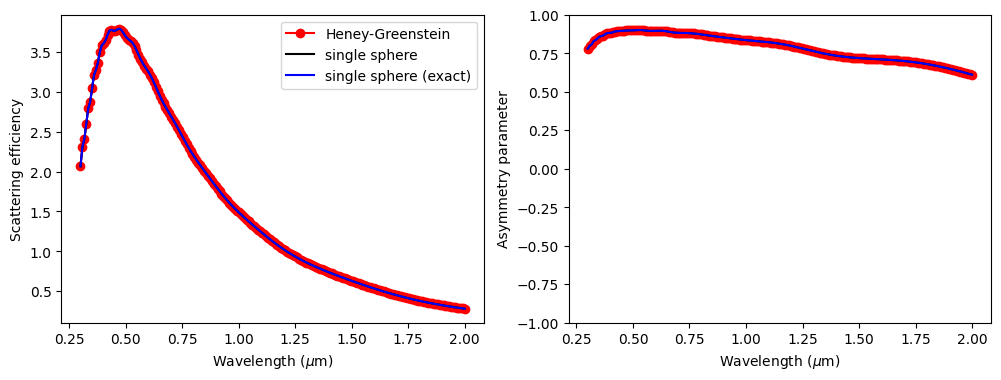

In [18]:
qsca_HG, gcos_HG = mie.scatter_from_phase_function(p_theta_HG)

fig, ax = plt.subplots(1,2, figsize = (12,4))
ax[0].plot(lam, qsca_HG, 'o-r', label = 'Heney-Greenstein')
ax[0].plot(lam, qsca_mie, '-k', label = 'single sphere')
ax[0].plot(lam, qsca, '-b', label = 'single sphere (exact)')
ax[0].legend()
ax[0].set_xlabel(r'Wavelength ($\mu$m)')
ax[0].set_ylabel('Scattering efficiency')

ax[1].plot(lam, gcos_HG, 'o-r', label = 'Heney-Greenstein')
ax[1].plot(lam, gcos_mie, '-k', label = 'single sphere')
ax[1].plot(lam, gcos, '-b', label = 'single sphere (exact)')
ax[1].set_xlabel(r'Wavelength ($\mu$m)')
ax[1].set_ylabel('Asymmetry parameter')
ax[1].set_ylim(-1,1)
plt.show()

## <a id='toc1_5_'></a>[Validating Heyney-Greenstein for hard-spheres](#toc0_)

### <a id='toc1_5_1_'></a>[Comparing scattering parameters extracted from Heyney-Greenstein](#toc0_)

In [19]:
p_theta_HG = mie.phase_scatt_HG(lam, gcos_dense, qsca_dense, theta=theta)

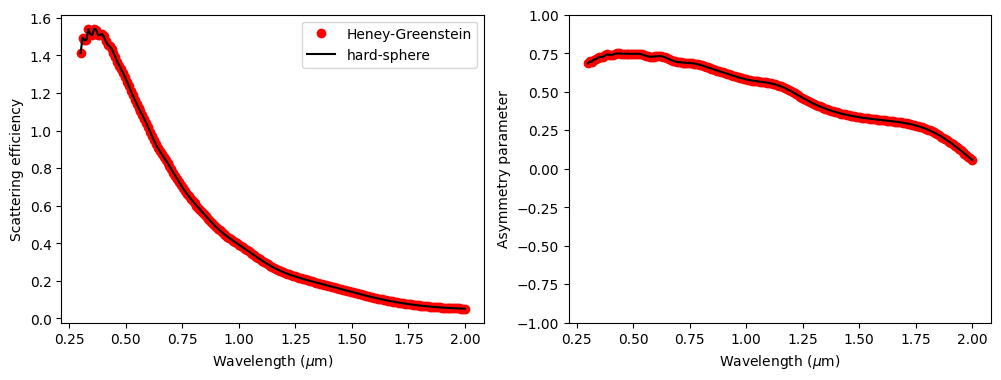

In [20]:
qsca_HG, gcos_HG = mie.scatter_from_phase_function(p_theta_HG)

fig, ax = plt.subplots(1,2, figsize = (12,4))
ax[0].plot(lam, qsca_HG, 'o r', label = 'Heney-Greenstein')
ax[0].plot(lam, qsca_dense, '-k', label = 'hard-sphere')
ax[0].legend()
ax[0].set_xlabel(r'Wavelength ($\mu$m)')
ax[0].set_ylabel('Scattering efficiency')

ax[1].plot(lam, gcos_HG, 'o r', label = 'Heney-Greenstein')
ax[1].plot(lam, gcos_dense, '-k', label = 'hard-sphere')
ax[1].set_xlabel(r'Wavelength ($\mu$m)')
ax[1].set_ylabel('Asymmetry parameter')
ax[1].set_ylim(-1,1)
plt.show()

### <a id='toc1_5_2_'></a>[Comparing phase functions](#toc0_)

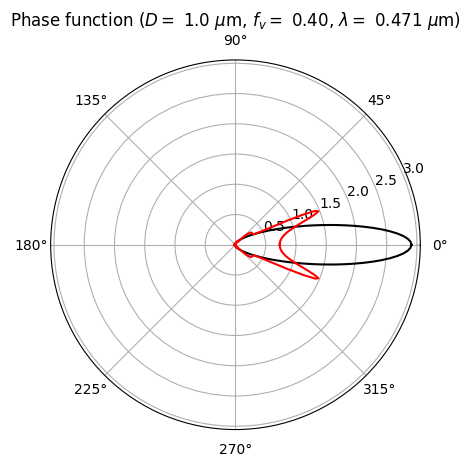

In [21]:
i_lam = 20
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(theta, p_theta_HG[lam[i_lam]], '-k')
ax.plot(theta, phase_scat_dense[lam[i_lam]], '-r')
ax.set_title(r'Phase function ($D =$ %.1f $\mu$m, $f_v =$ %.2f, $\lambda =$ %.3f $\mu$m)' % (Dp, fv, lam[i_lam]))
plt.show()